In [1]:
import torch
from torch import nn
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

torch.manual_seed(42)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(
    "../data/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    "../data/val",
    transform=val_transforms
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


In [2]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    shuffle=False
)

images, labels = next(iter(train_dataloader))

print(images.shape)
print(labels.shape)
print(images.min())
print(images.max())

torch.Size([64, 3, 224, 224])
torch.Size([64])
tensor(-1.7925)
tensor(2.6400)


In [3]:
model = models.resnet18(weights="DEFAULT")

model.fc = nn.Linear(model.fc.in_features, out_features=10)

model.load_state_dict(
    torch.load('../models/TL_Frozen_Backbone.pt')
)

# Freeze Backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Classifier
for param in model.fc.parameters():
    param.requires_grad = True

# Unfreeze layer4
for param in model.layer4.parameters():
    param.requires_grad = True

model = model.to(device)

for name, param in model.named_parameters():
    if param.requires_grad:
        print(name)

layer4.0.conv1.weight
layer4.0.bn1.weight
layer4.0.bn1.bias
layer4.0.conv2.weight
layer4.0.bn2.weight
layer4.0.bn2.bias
layer4.0.downsample.0.weight
layer4.0.downsample.1.weight
layer4.0.downsample.1.bias
layer4.1.conv1.weight
layer4.1.bn1.weight
layer4.1.bn1.bias
layer4.1.conv2.weight
layer4.1.bn2.weight
layer4.1.bn2.bias
fc.weight
fc.bias


In [4]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall
)
from torch.optim import Adam

train_acc_metric = MulticlassAccuracy(num_classes=10).to(device)
train_prec_metric = MulticlassPrecision(num_classes=10, average="macro").to(device)
train_rec_metric = MulticlassRecall(num_classes=10, average="macro").to(device)

val_acc_metric = MulticlassAccuracy(num_classes=10).to(device)
val_prec_metric = MulticlassPrecision(num_classes=10, average="macro").to(device)
val_rec_metric = MulticlassRecall(num_classes=10, average="macro").to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=filter(lambda p: p.requires_grad, model.parameters()), lr=1e-5, weight_decay=1e-4)

In [5]:
import pandas as pd

results = []
epochs = 10

best_val_acc = 0

for epoch in range(epochs):
    history = {}
    train_running_loss = 0

    history["epoch"] = epoch + 1

    # Training Loop
    model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        output = model(images)

        loss = loss_fn(output, labels)
        train_running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_acc_metric.update(output, labels)
        train_prec_metric.update(output, labels)
        train_rec_metric.update(output, labels)

    train_loss = train_running_loss / len(train_dataloader)

    history["train_loss"] = train_loss
    history["train_acc"] = train_acc_metric.compute().item()
    history["train_prec"] = train_prec_metric.compute().item()
    history["train_rec"] = train_rec_metric.compute().item()

    train_acc_metric.reset()
    train_prec_metric.reset()
    train_rec_metric.reset()


    # Validation Loop
    model.eval()

    val_running_loss = 0

    with torch.inference_mode():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)

            loss = loss_fn(output, labels)
            val_running_loss += loss.item()

            val_acc_metric.update(output, labels)
            val_prec_metric.update(output, labels)
            val_rec_metric.update(output, labels)

        val_loss = val_running_loss / len(val_dataloader)

        history["val_loss"] = val_loss
        history["val_acc"] = val_acc_metric.compute().item()
        history["val_prec"] = val_prec_metric.compute().item()
        history["val_rec"] = val_rec_metric.compute().item()
    
        val_acc_metric.reset()
        val_prec_metric.reset()
        val_rec_metric.reset()

    print(f"Epoch {epoch + 1} :-")
    print(f"Train Loss: {history['train_loss']:.2f} | Train Acc: {history['train_acc']*100:.2f}% | Train Prec: {history['train_prec']*100:.2f}% | Train Rec: {history['train_rec']*100:.2f}%")
    print(f"Val Loss: {history['val_loss']:.2f} | Val Acc: {history['val_acc']*100:.2f}% | Val Prec: {history['val_prec']*100:.2f}% | Val Rec: {history['val_rec']*100:.2f}%")

    if(history['val_acc'] >= best_val_acc):
        best_val_acc = history['val_acc']
        torch.save(model.state_dict(), "../models/TL_FineTune_Backbone.pt")
        print(f"Best Model Saved!! Val Acc: {history['val_acc']*100:.2f}%")
    print("\n")
    results.append(history)

df = pd.DataFrame(results)

Epoch 1 :-
Train Loss: 0.16 | Train Acc: 94.45% | Train Prec: 94.45% | Train Rec: 94.45%
Val Loss: 0.13 | Val Acc: 95.39% | Val Prec: 95.47% | Val Rec: 95.39%
Best Model Saved!! Val Acc: 95.39%


Epoch 2 :-
Train Loss: 0.11 | Train Acc: 96.18% | Train Prec: 96.19% | Train Rec: 96.18%
Val Loss: 0.11 | Val Acc: 96.11% | Val Prec: 96.13% | Val Rec: 96.11%
Best Model Saved!! Val Acc: 96.11%


Epoch 3 :-
Train Loss: 0.08 | Train Acc: 97.20% | Train Prec: 97.23% | Train Rec: 97.20%
Val Loss: 0.10 | Val Acc: 96.47% | Val Prec: 96.51% | Val Rec: 96.47%
Best Model Saved!! Val Acc: 96.47%


Epoch 4 :-
Train Loss: 0.06 | Train Acc: 97.95% | Train Prec: 97.98% | Train Rec: 97.95%
Val Loss: 0.09 | Val Acc: 96.61% | Val Prec: 96.65% | Val Rec: 96.61%
Best Model Saved!! Val Acc: 96.61%


Epoch 5 :-
Train Loss: 0.05 | Train Acc: 98.39% | Train Prec: 98.40% | Train Rec: 98.39%
Val Loss: 0.09 | Val Acc: 96.48% | Val Prec: 96.58% | Val Rec: 96.48%


Epoch 6 :-
Train Loss: 0.04 | Train Acc: 98.58% | Train

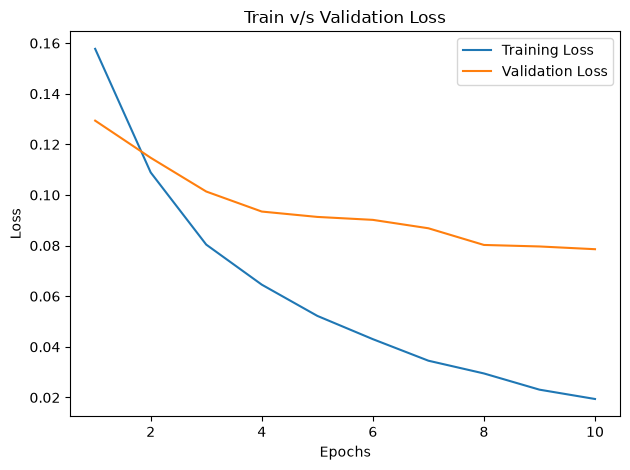

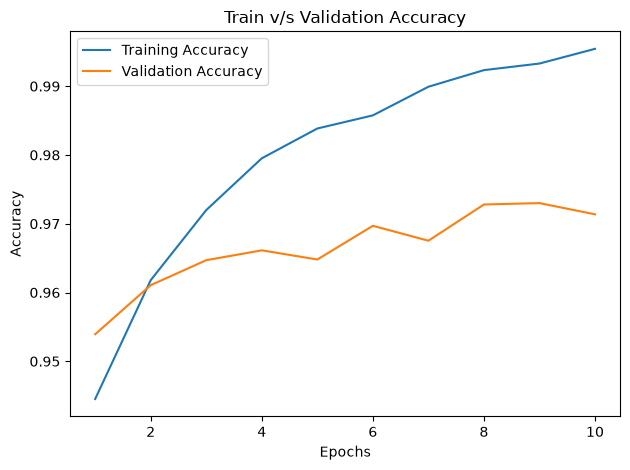

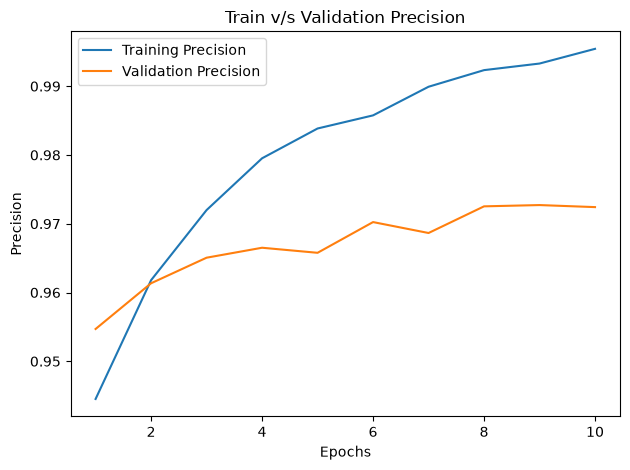

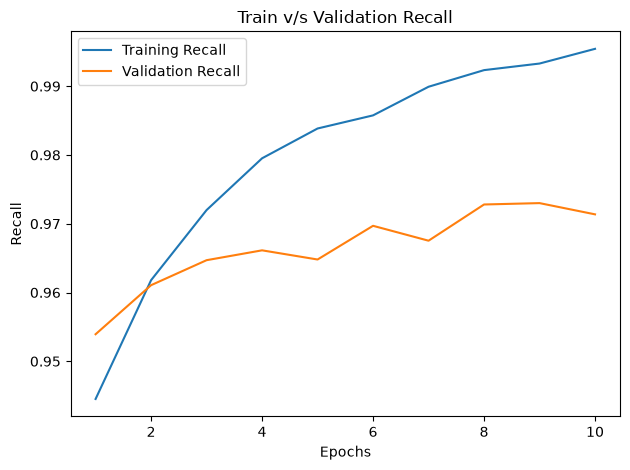

In [6]:
import matplotlib.pyplot as plt

def plot_metric(x, y1, y2, metric):
    xlabel = df[x]
    y1label = df[y1]
    y2label = df[y2]

    plt.title(f"Train v/s Validation {metric}")

    plt.plot(xlabel, y1label, label=f"Training {metric}")
    plt.plot(xlabel, y2label, label=f"Validation {metric}")

    plt.xlabel("Epochs")
    plt.ylabel(f"{metric}")

    plt.legend()
    plt.tight_layout()
    plt.show()


plot_metric('epoch', 'train_loss', 'val_loss', 'Loss')
plot_metric('epoch', 'train_acc', 'val_acc', 'Accuracy')
plot_metric('epoch', 'train_rec', 'val_prec', 'Precision')
plot_metric('epoch', 'train_rec', 'val_rec', 'Recall')